In [1]:
# ! pip install vnstock3 joblib matplotlib scikit-learn icecream

In [1]:
# from update_data import *
from static import *
from stock_data import *
from scipy.stats.mstats import winsorize
from bao import *

# from scipy.stats.mstats import winsorize
stock = StockData("./data/stock/", "./stock_dictionary.json")

In [ ]:
stock_data = stock.get_data()
indies_data = stock.get_indices_data()
whole_data = pd.concat([stock_data] + indies_data, axis=0)

In [5]:
# Compute market level return
market = (
    whole_data.groupby(["exchange", "time"])[
        [
            "return_weighted",
            "log_return_weighted",
        ]
    ]
    .sum()
    .reset_index()
)

## winsorize the outliner

In [6]:
market_winsored = pd.DataFrame()
for i in market["exchange"].unique():
    temp = market.loc[market["exchange"] == i]
    temp["return_weighted"] = winsorize(
        temp["return_weighted"], limits=[0.05, 0.05]
    )
    temp["log_return_weighted"] = winsorize(
        temp["log_return_weighted"], limits=[0.05, 0.05]
    )
    market_winsored = pd.concat([market_winsored, temp], axis=0)
    # Detect outliers using Z-score

# test stationary

In [8]:
from test_and_visualize import *

In [9]:
for i in market_winsored["exchange"].unique():
    if i not in ["BOND", "DELISTED"]:
        temp = market_winsored[market_winsored["exchange"] == i][
            "return_weighted"
        ]
        print(i, flush=True)
        print("adf_test result:", flush=True)
        adf_test(temp, 0.01)
        print("kpss_test result:", flush=True)
        kpss_test(temp, 0.01)

HNX
adf_test result:


ic| adf_statistic: np.float64(-5.900547991482211)
    p_value: np.float64(2.784726840987283e-07)
    critical_values: {'1%': np.float64(-3.4325731694738972),
                      '10%': np.float64(-2.5672928784456595),
                      '5%': np.float64(-2.862522249592085)}


Judgment: The series is likely stationary (Reject null hypothesis).


kpss_test result:


The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

ic| kpss_statistic: np.float64(2.386163853789992)
    p_value: np.float64(0.01)
    critical_values: {'1%': 0.739, '10%': 0.347, '2.5%': 0.574, '5%': 0.463}


Judgment: The series is likely stationary (Fail to reject null hypothesis).


HSX
adf_test result:


...

Judgment: The series is likely stationary (Fail to reject null hypothesis).


vni
adf_test result:


ic| adf_statistic: np.float64(-27.830463530328988)
    p_value: 0.0
    critical_values: {'1%': np.float64(-3.432737101522179),
                      '10%': np.float64(-2.567331423936805),
                      '5%': np.float64(-2.8625946496914145)}


Judgment: The series is likely stationary (Reject null hypothesis).


kpss_test result:


The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

ic| kpss_statistic: np.float64(0.18088818850635835)
    p_value: np.float64(0.1)
    critical_values: {'1%': 0.739, '10%': 0.347, '2.5%': 0.574, '5%': 0.463}


Judgment: The series is likely stationary (Fail to reject null hypothesis).




# Seasonarity

* with the cycle is 2 year: the trend is more observable

HNX


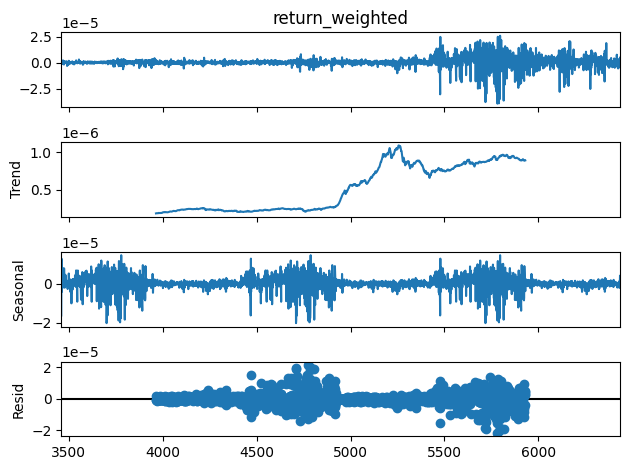

HSX


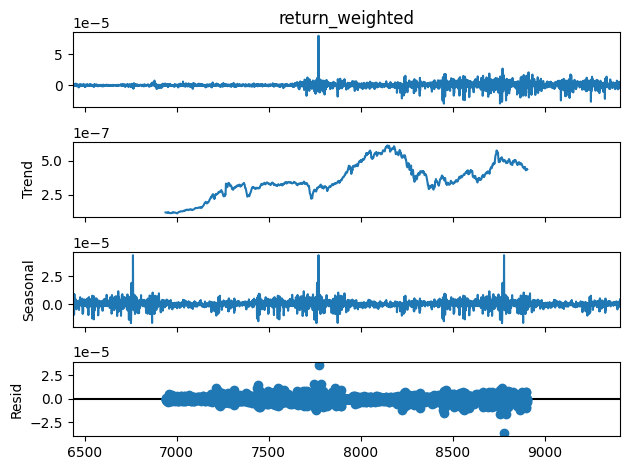

UPCOM


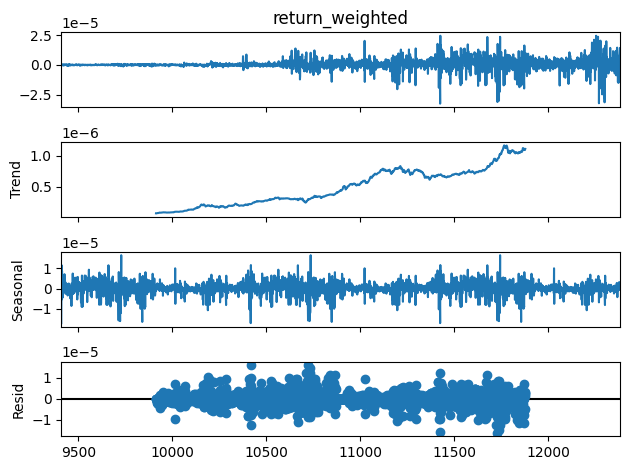

vn30
plot 1 year cycles


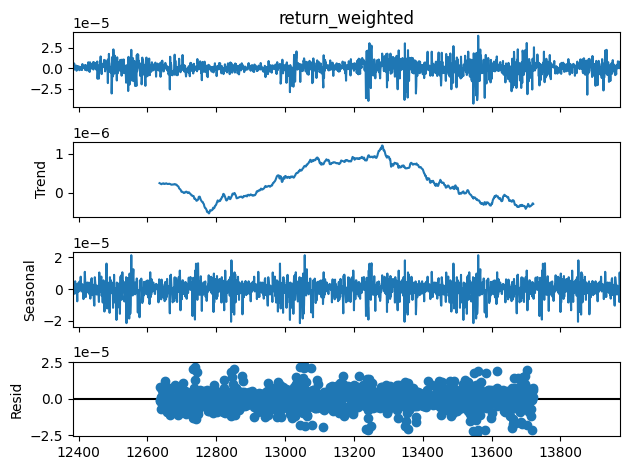

vni


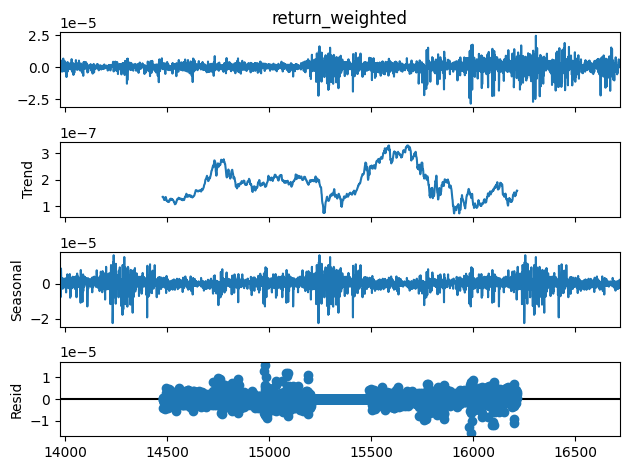

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

period = 2
for i in market["exchange"].unique():
    if i not in ["BOND", "DELISTED"]:
        print(i)
        try:
            temp = market[market["exchange"] == i]["return_weighted"]
            result = seasonal_decompose(
                temp, model="additive", period=period * 252 * 2
            )
            result.plot()
            plt.close()
        except (ValueError, TypeError):
            print("plot 1 year cycles")

            result = seasonal_decompose(
                temp, model="additive", period=period * 252
            )
            result.plot()
            plt.close()

* With 1 year cycle: the trend might not be so clear

ic| i: 'HNX'


'HNX'

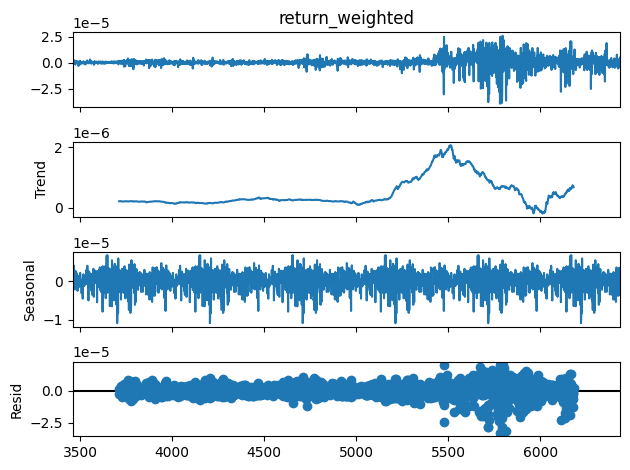

ic| i: 'HSX'


'HSX'

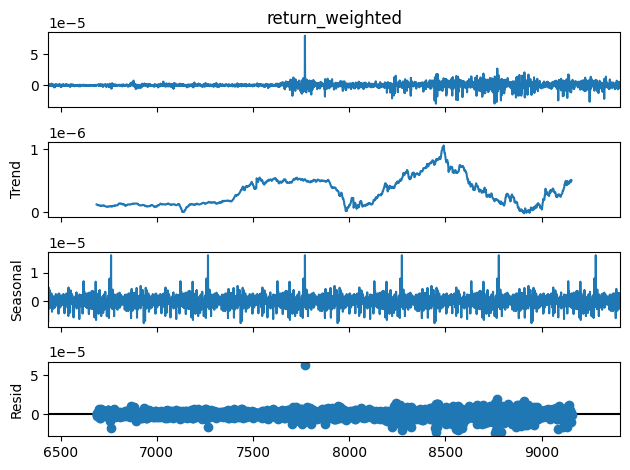

ic| i: 'UPCOM'


'UPCOM'

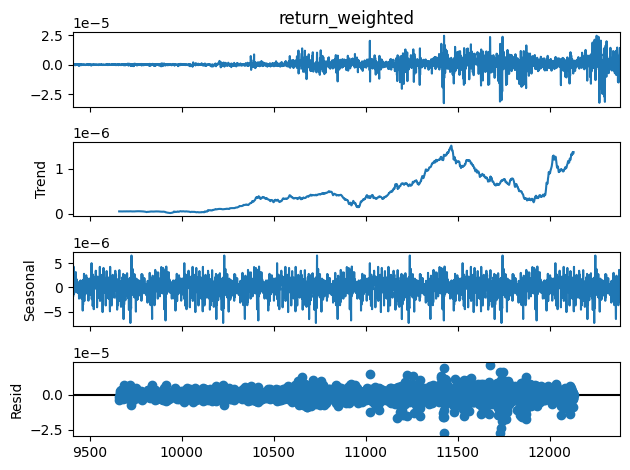

ic| i: 'vn30'


'vn30'

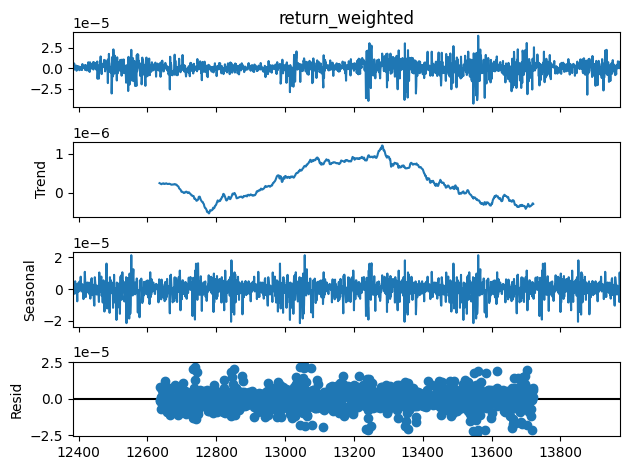

ic| i: 'vni'


'vni'

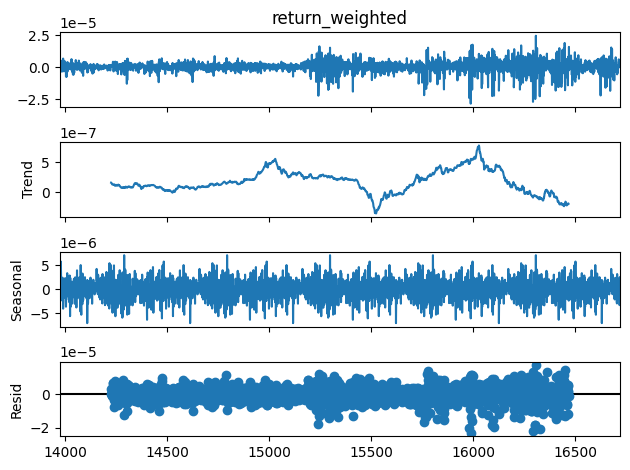

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

period = 1
for i in market["exchange"].unique():
    if i not in ["BOND", "DELISTED"]:
        ic(i)
        try:
            temp = market[market["exchange"] == i]["return_weighted"]
            result = seasonal_decompose(
                temp, model="additive", period=period * 252 * 2
            )
            result.plot()
            plt.close()
        except ValueError:
            print("plot 1 year cycles")
            result = seasonal_decompose(
                temp, model="additive", period=period * 252
            )
            result.plot()
            plt.close()

HSX


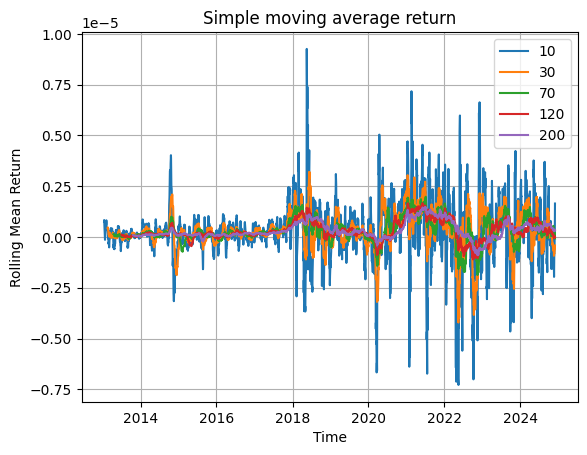

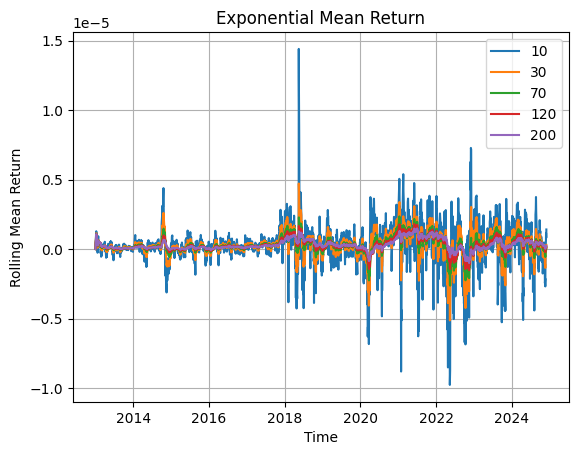

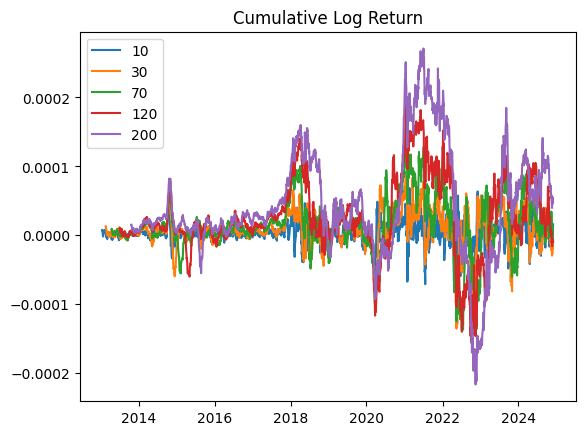

vn30


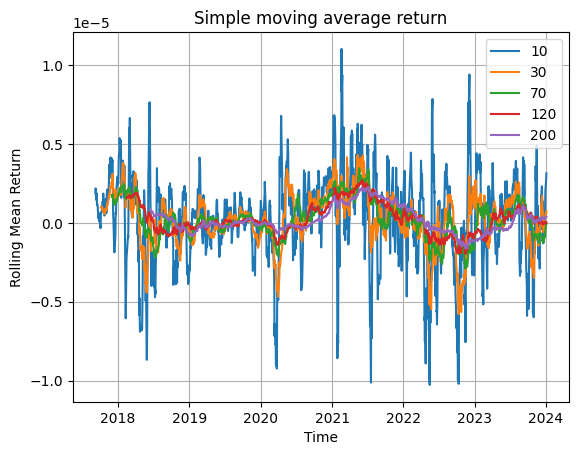

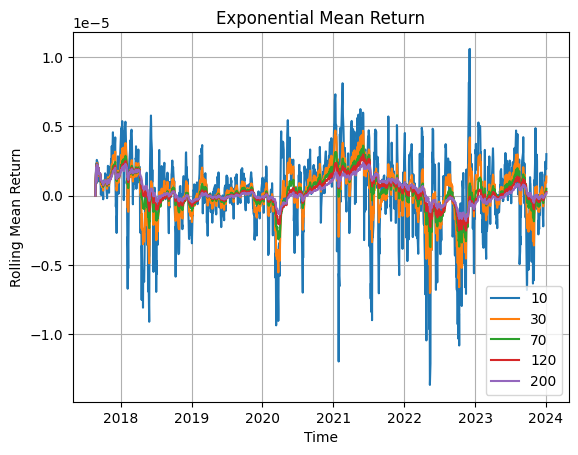

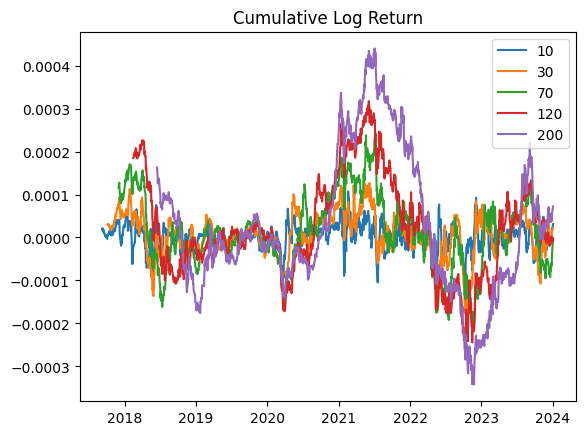

vni


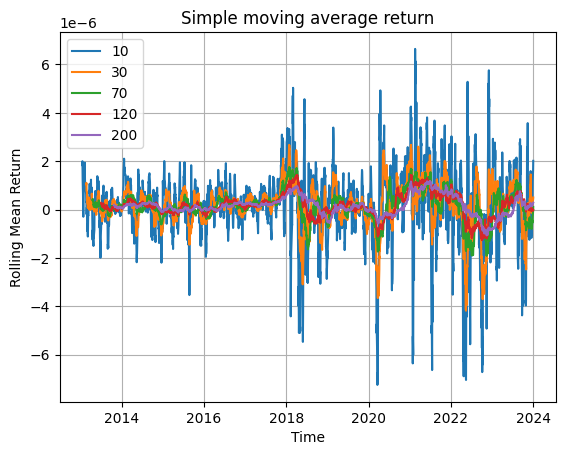

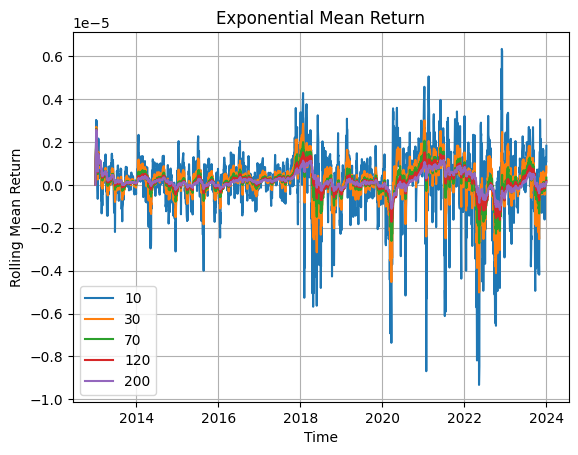

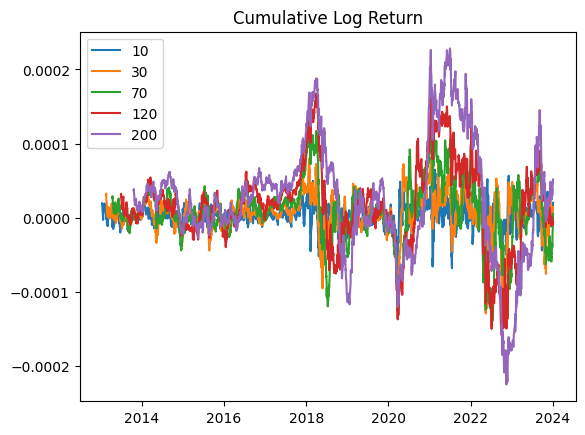

In [34]:
windows = [10, 30, 70, 120, 200]  # number of trading dates
for i in market["exchange"].unique():
    if i in ["HSX", "vni", "vn30"]:
        temp = market[market["exchange"] == i]
        print(i)
        simple_moving_average_visual(temp, "return_weighted", windows)
        exponential_moving_average_visual(
            temp, "return_weighted", windows
        )
        cumulative_visual(temp, "log_return_weighted", windows)

# Auto Regression

'HSX'

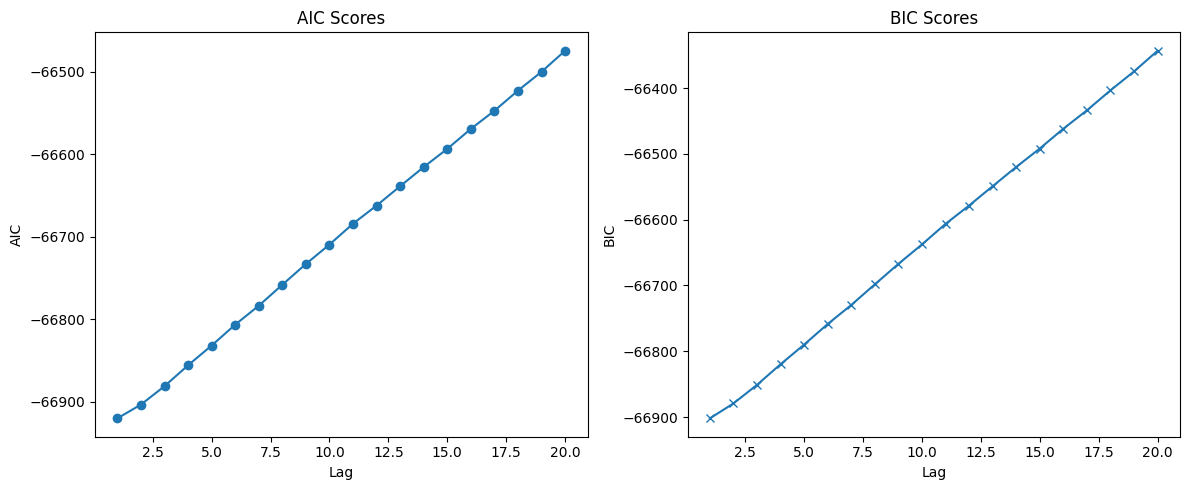

{'best_aic_lag': (1, np.float64(-66920.01049064362)),
 'best_bic_lag': (1, np.float64(-66902.01851017462))}

ic| _mape_index =:             mse  code
                   0  2.530751e-12    12
    esults[:        mape  code
             0  4.942399     2


'vn30'

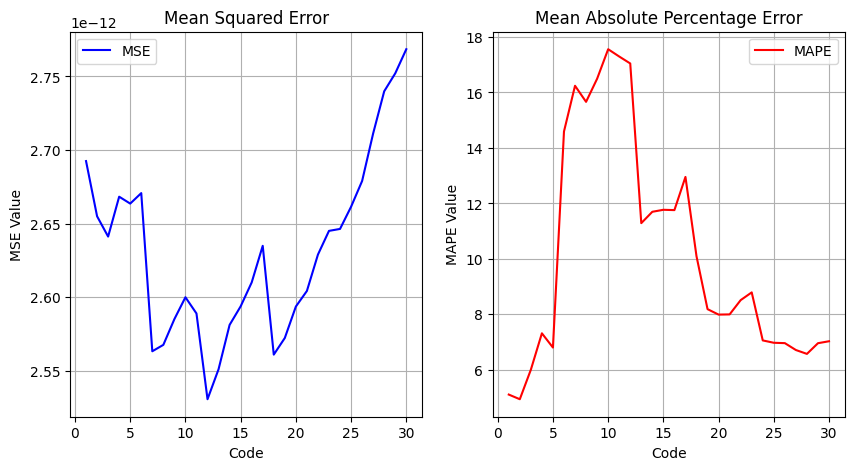

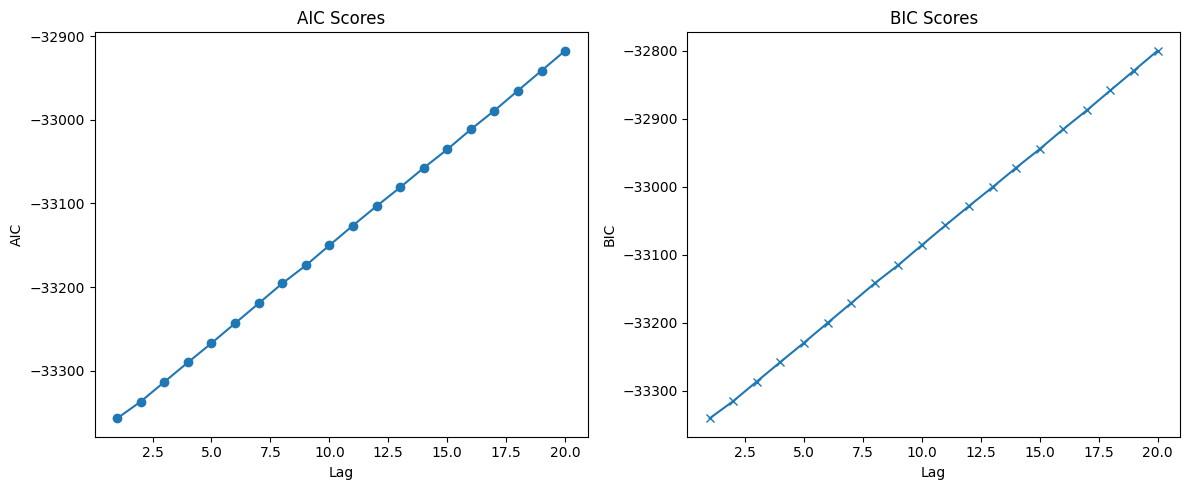

{'best_aic_lag': (1, np.float64(-33356.66800919975)),
 'best_bic_lag': (1, np.float64(-33340.553541314104))}

ic| _mape_index =:             mse  code
                   0  2.075123e-11     3
    esults[:        mape  code
             0  1.172693     1


'vni'

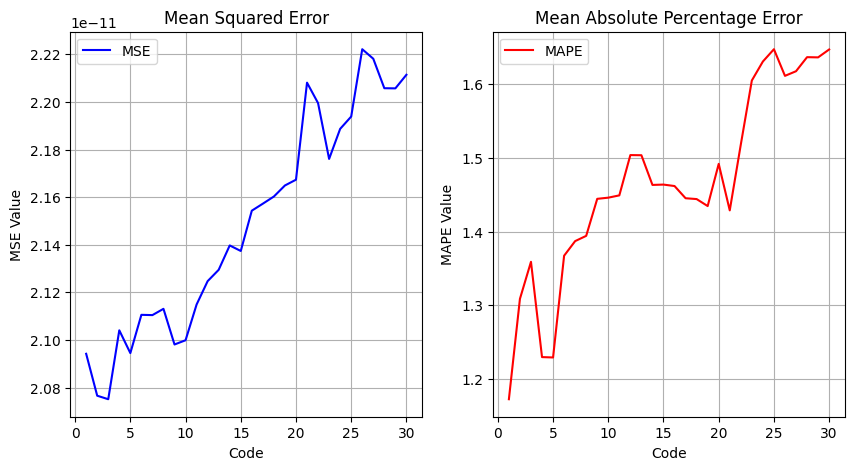

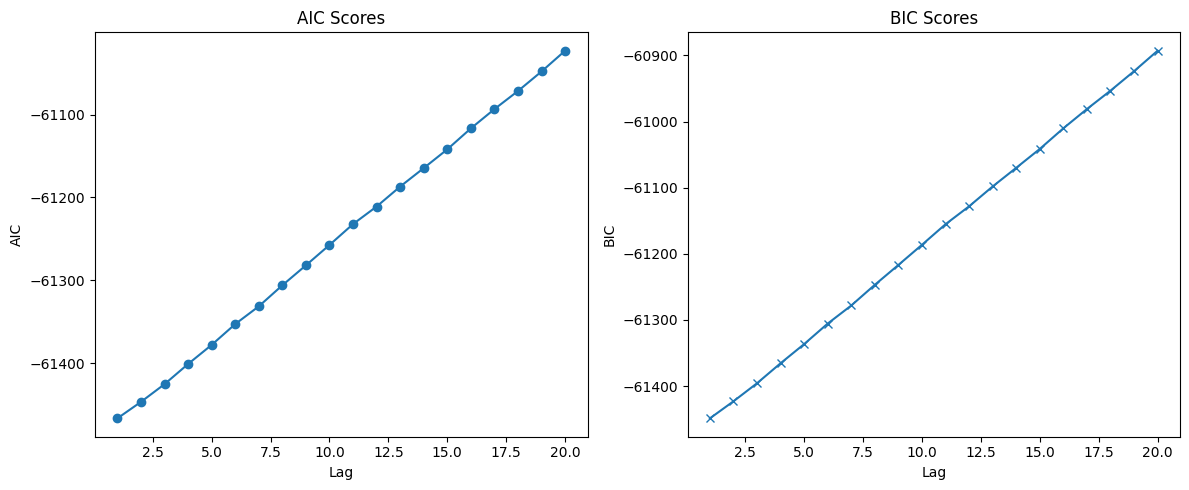

{'best_aic_lag': (1, np.float64(-61466.48788505363)),
 'best_bic_lag': (1, np.float64(-61448.7363690871))}

ic| _mape_index =:             mse  code
                   0  6.142439e-12     1
    esults[:        mape  code
             0  1.126454     1


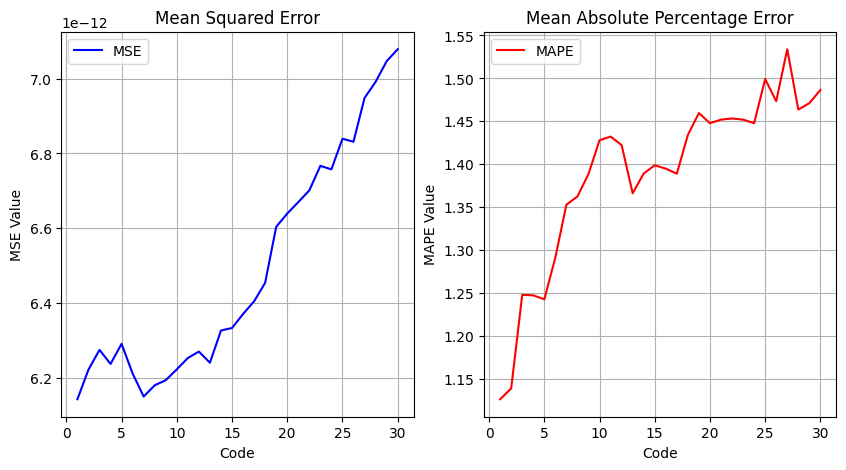

In [35]:
from AR import *

for i in market["exchange"].unique():
    if i in ["HSX", "vni", "vn30"]:
        i
        data = market_winsored[market_winsored["exchange"] == i]
        data.index = pd.date_range(
            start=data["time"].min(),
            periods=len(data),
            freq="B",
        )
        info_criteria_selection(data["return_weighted"])
        # using mean_squared_error
        result_return = plot_best_lag_model(data["return_weighted"])

'HSX'

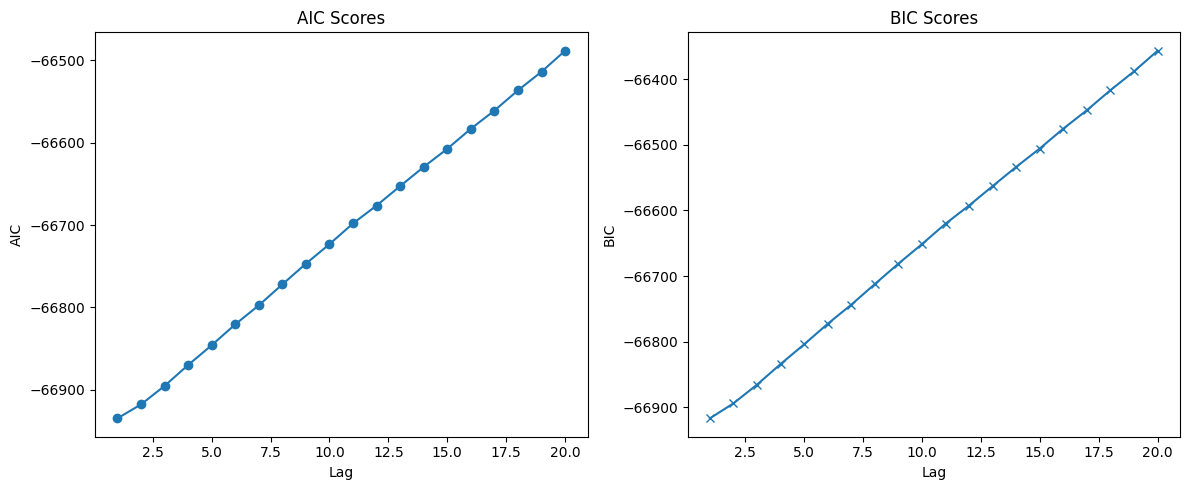

{'best_aic_lag': (1, np.float64(-66934.57569718665)),
 'best_bic_lag': (1, np.float64(-66916.58371671765))}

ic| _mape_index =:             mse  code
                   0  2.547573e-12    12
    esults[:        mape  code
             0  1.305871     2


'vn30'

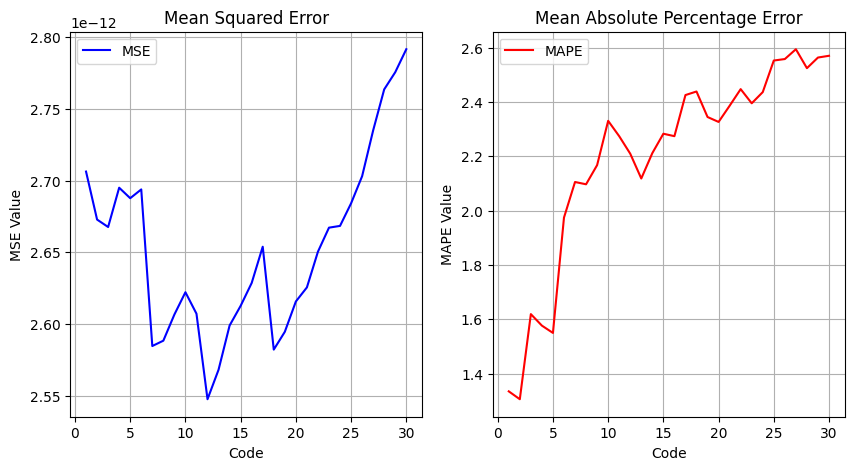

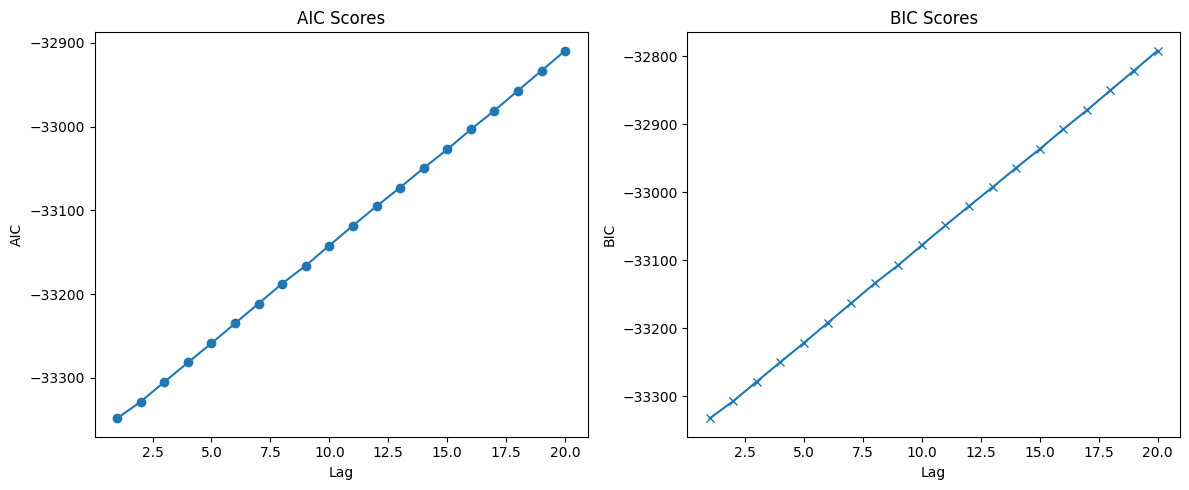

{'best_aic_lag': (1, np.float64(-33348.33839396713)),
 'best_bic_lag': (1, np.float64(-33332.22392608149))}

ic| _mape_index =:             mse  code
                   0  2.077648e-11     3
    esults[:        mape  code
             0  1.153376     1


'vni'

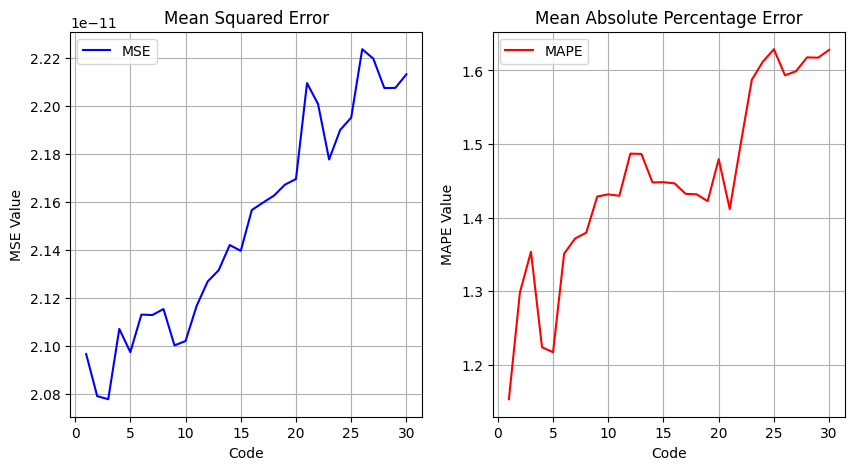

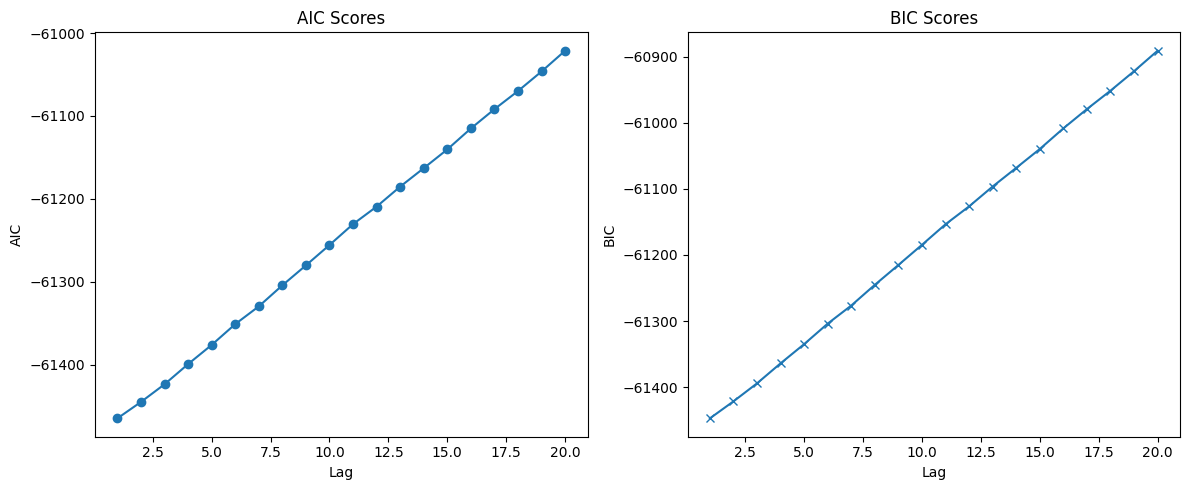

{'best_aic_lag': (1, np.float64(-61464.771216806)),
 'best_bic_lag': (1, np.float64(-61447.01970083947))}

ic| _mape_index =:             mse  code
                   0  6.155160e-12     1
    esults[:        mape  code
             0  1.118832     1


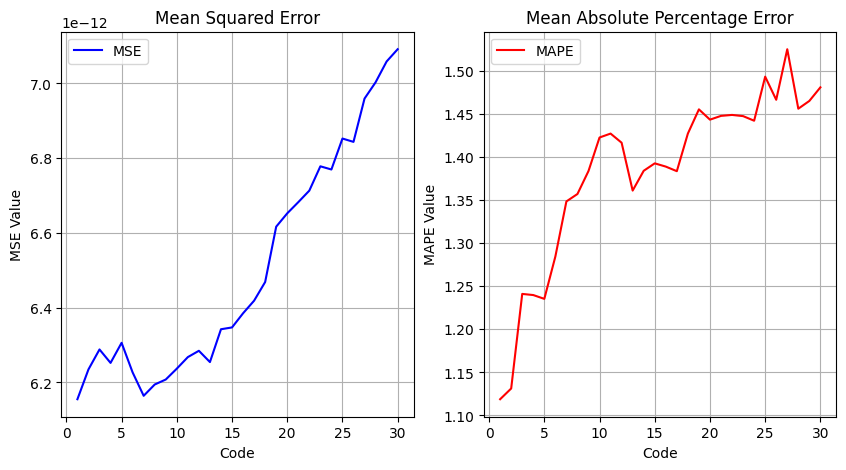

In [36]:
from AR import *

for i in market["exchange"].unique():
    if i in ["HSX", "vni", "vn30"]:
        i
        data = market_winsored[market_winsored["exchange"] == i]
        data.index = pd.date_range(
            start=data["time"].min(),
            periods=len(data),
            freq="B",
        )

        info_criteria_selection(data["log_return_weighted"])
        # using mean_squared_error
        result_log_return = plot_best_lag_model(
            data["log_return_weighted"]
        )

ic| i: 'vni'


'vni'

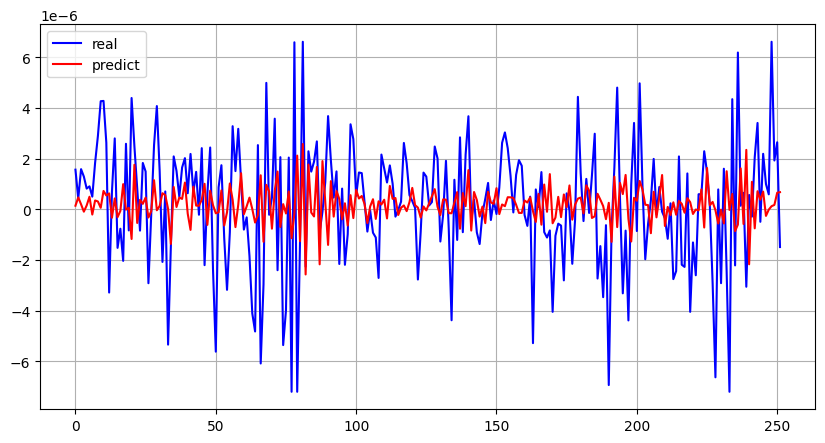

ic| i: 'HSX'


'HSX'

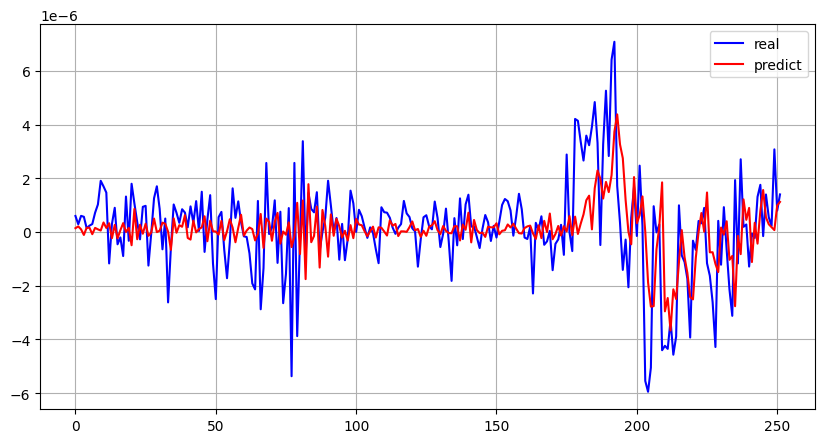

ic| i: 'vn30'


'vn30'

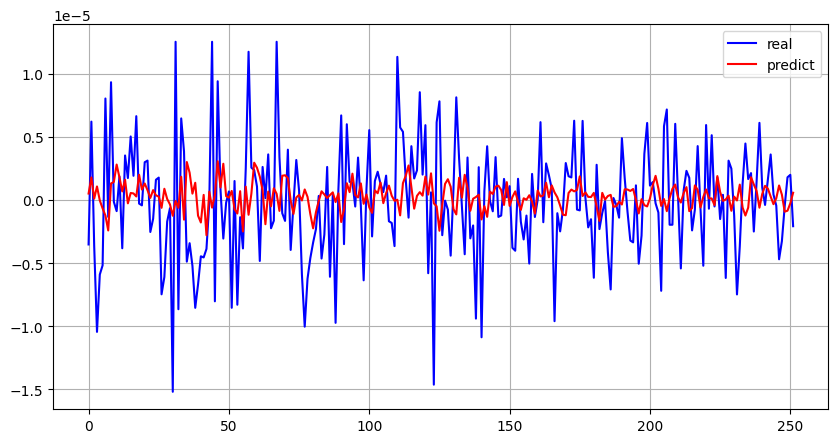

In [24]:
for i in ["vni", "HSX", "vn30"]:
    ic(i)
    visualize(
        np.asarray(
            market_winsored[market_winsored["exchange"] == i][
                "return_weighted"
            ]
        ),
        12,
    )

## MA modeling

In [ ]:
from MA import *

'HSX'

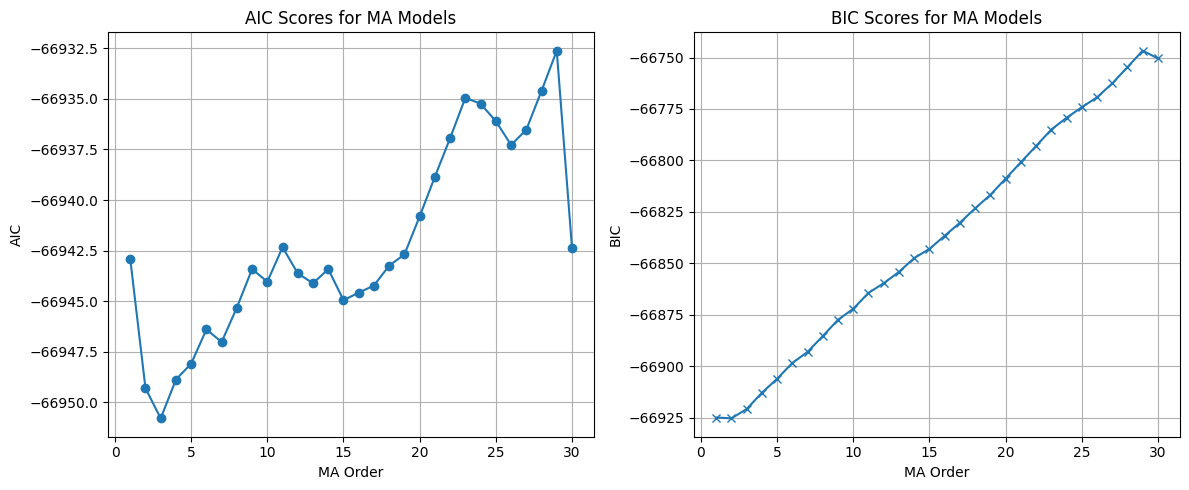

{'best_aic_order': (3, np.float64(-66950.7932336726)),
 'best_bic_order': (2, np.float64(-66925.31610590153))}

'vn30'

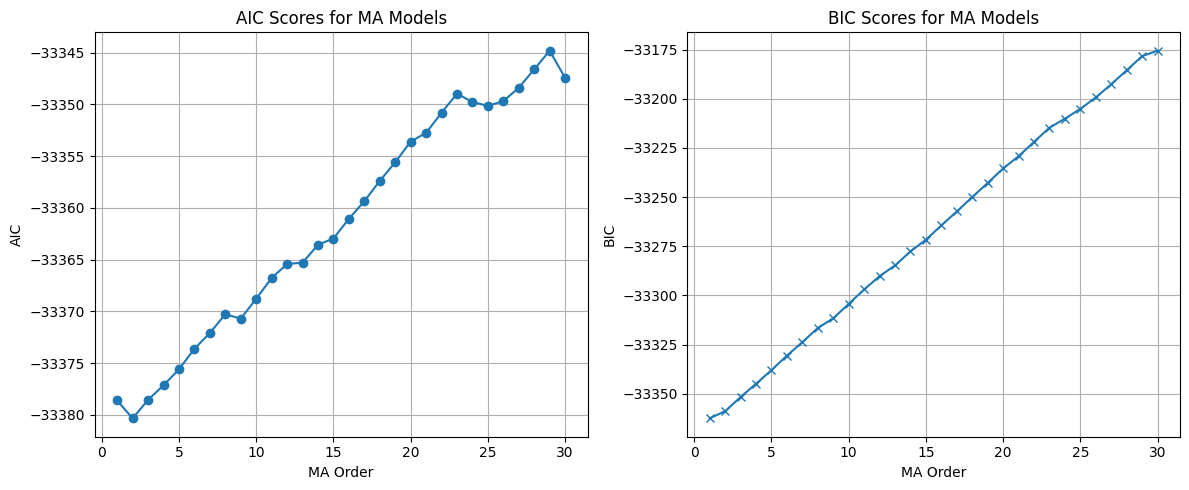

{'best_aic_order': (2, np.float64(-33380.34856563122)),
 'best_bic_order': (1, np.float64(-33362.507477737745))}

'vni'

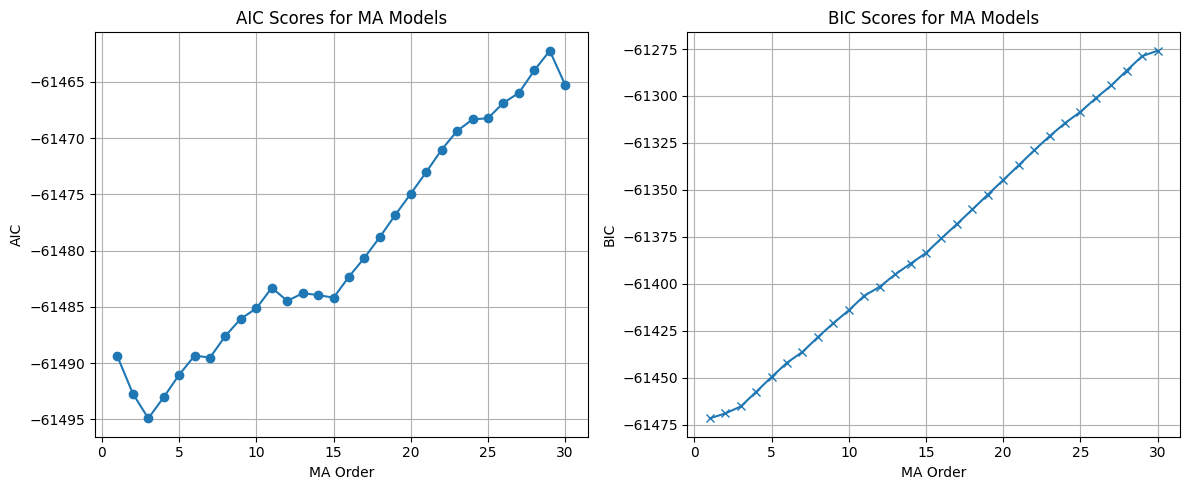

{'best_aic_order': (3, np.float64(-61494.921795586895)),
 'best_bic_order': (1, np.float64(-61471.657199366535))}

In [8]:
for i in market["exchange"].unique():
    if i in ["HSX", "vni", "vn30"]:
        i
        data = market_winsored[market_winsored["exchange"] == i]
        data.index = pd.date_range(
            start=data["time"].min(),
            periods=len(data),
            freq="B",
        )
        info_criteria_selection_ma(data["return_weighted"])

'HSX'

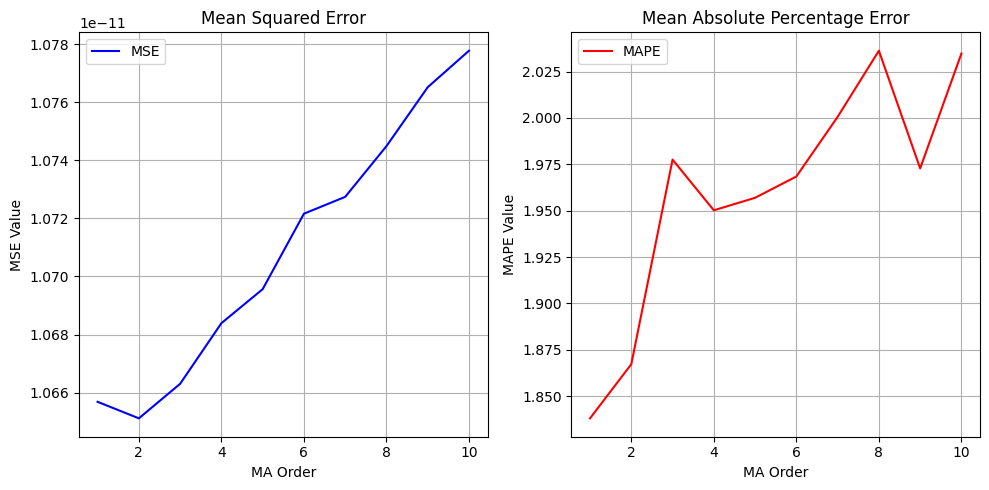

min mse:            mse  order
0  1.065115e-11      2, min_mape:       mape  order
0  1.838083      1


,mse,mape,order
0,1.065684e-11,1.838083,1
0,1.065115e-11,1.867261,2
0,1.066304e-11,1.977534,3
0,1.068391e-11,1.950207,4
0,1.069561e-11,1.956955,5
0,1.072159e-11,1.968437,6
0,1.072739e-11,2.000577,7
0,1.074485e-11,2.036226,8
0,1.076513e-11,1.972805,9
0,1.077770e-11,2.034723,10


'vn30'

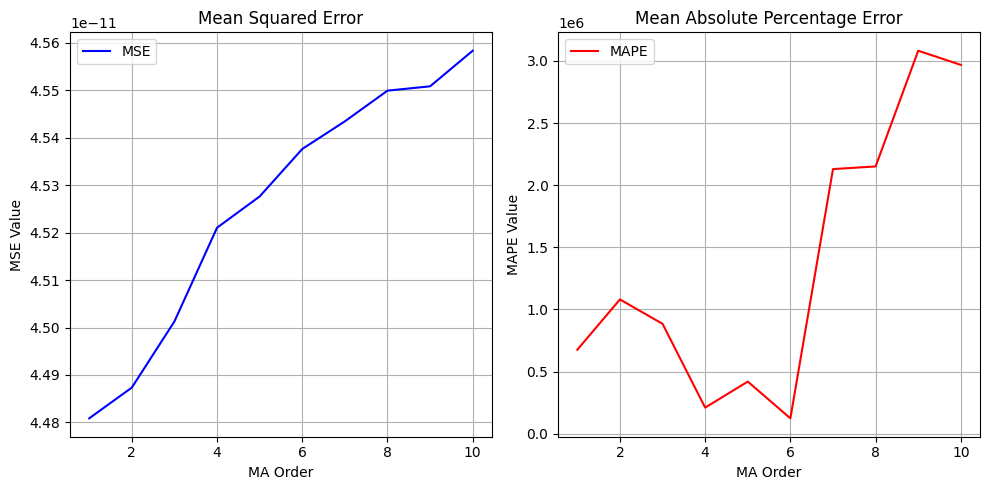

min mse:            mse  order
0  4.480861e-11      1, min_mape:            mape  order
0  123657.650795      6


,mse,mape,order
0,4.480861e-11,6.757859e+05,1
0,4.487342e-11,1.080438e+06,2
0,4.501283e-11,8.842216e+05,3
0,4.521041e-11,2.099296e+05,4
0,4.527630e-11,4.192457e+05,5
0,4.537637e-11,1.236577e+05,6
0,4.543463e-11,2.129391e+06,7
0,4.549937e-11,2.150632e+06,8
0,4.550845e-11,3.081912e+06,9
0,4.558352e-11,2.967839e+06,10


'vni'

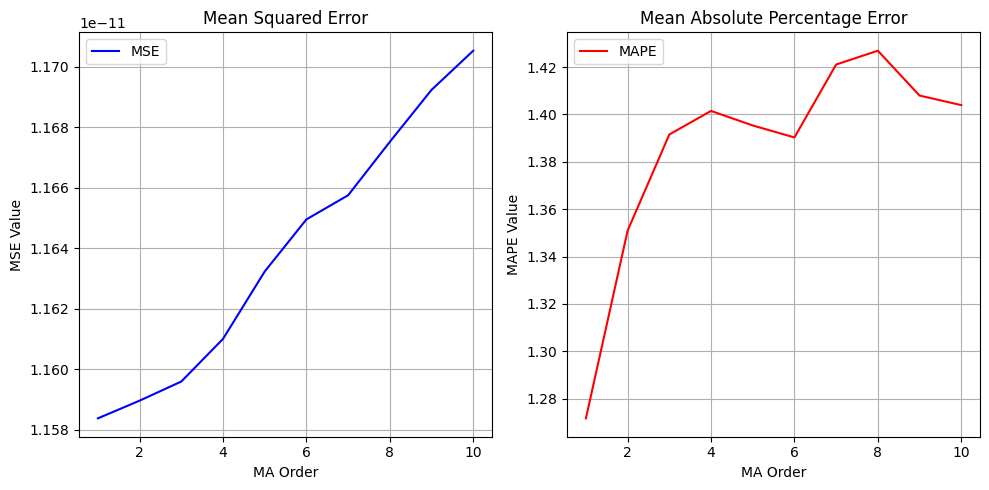

min mse:            mse  order
0  1.158371e-11      1, min_mape:       mape  order
0  1.271724      1


,mse,mape,order
0,1.158371e-11,1.271724,1
0,1.158956e-11,1.350963,2
0,1.159589e-11,1.391535,3
0,1.160999e-11,1.401479,4
0,1.163227e-11,1.395342,5
0,1.164950e-11,1.390283,6
0,1.165748e-11,1.421064,7
0,1.167513e-11,1.426895,8
0,1.169232e-11,1.407969,9
0,1.170527e-11,1.403932,10


In [7]:
for i in market["exchange"].unique():
    if i in ["HSX", "vni", "vn30"]:
        i
        data = market_winsored[market_winsored["exchange"] == i]
        data.index = pd.date_range(
            start=data["time"].min(),
            periods=len(data),
            freq="B",
        )
        plot_best_ma_model(data["return_weighted"])